In [1]:
from src.union_find import uf_cluster_growth
from src.uf_visualization import visualize_uf_run, final_visualize
from src.surface_graph import Create_Dummy_Surface_code_graph
from src.peeling_algo import find_error_chain

In [2]:
import stim
import networkx as nx
import matplotlib.pyplot as plt
import math
import random

In [3]:
d = 13
r = 1
stab_type = "z" 

circuit = stim.Circuit.generated(
    f"surface_code:rotated_memory_{stab_type}",
    distance=d,
    rounds=r,
    before_round_data_depolarization=0.05, 
    before_measure_flip_probability=0.01,
    after_reset_flip_probability= 0.001
)

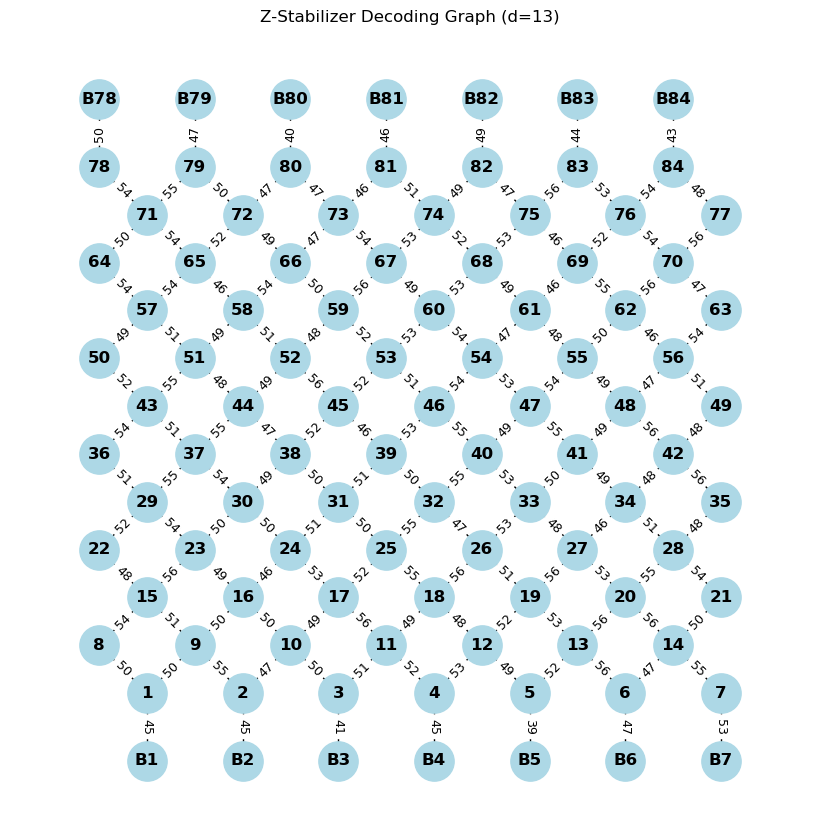

In [4]:
# Dynamically Generate Coordinate Maps

coords = circuit.get_detector_coordinates()
spatial_coords = set()

for det_id, c in coords.items():
    if c[2] == 1.0: 
        spatial_coords.add((c[0], c[1]))

sorted_coords = sorted(list(spatial_coords), key=lambda c: (c[1], c[0]))

# Map 1: For translating Stim (Coordinate -> Node ID)
coord_to_node = {coord: idx + 1 for idx, coord in enumerate(sorted_coords)}

# Map 2: For NetworkX plotting (Node ID -> Coordinate)
pos = {node_id: coord for coord, node_id in coord_to_node.items()}


# Build the Graph

G = nx.Graph()
G.add_nodes_from(coord_to_node.values())

model = circuit.detector_error_model(decompose_errors=True)
edge_count = 0

for instruction in model:
    if instruction.type == "error":
        p = instruction.args_copy()[0]
        weight = int(round(10*math.log((1 - p) / p))) + random.randint(0,10)
        
        raw_targets = [t.val for t in instruction.targets_copy() if t.is_relative_detector_id()]
        
        my_targets = []
        for stim_id in raw_targets:
            x, y = coords[stim_id][0], coords[stim_id][1]
            if (x, y) in coord_to_node: 
                my_targets.append(coord_to_node[(x, y)])
        
        if len(my_targets) == 2:
            if my_targets[0] == my_targets[1]:
                continue 
            else:
                G.add_edge(my_targets[0], my_targets[1], weight=weight)
                edge_count += 1
                
        elif len(my_targets) == 1:
            i = my_targets[0]
            for stim_id in raw_targets:
                x_, y_ = coords[stim_id][0], coords[stim_id][1]
            if stab_type == 'x':
                if x_ <4:
                    pos["B"+str(i)] = (x_ - 2.828, y_)
                else:
                    pos["B"+str(i)] = (x_ + 2.828, y_)
            else:
                if y_ <4:
                    pos["B"+str(i)] = (x_ , y_ -2.828)
                else:
                    pos["B"+str(i)] = (x_ , y_ +2.828)
            G.add_edge(my_targets[0], "B"+str(i), weight=weight)
            edge_count += 1



# Draw the Graph

plt.figure(figsize=(8,8))
nx.draw(
    G, 
    pos, 
    with_labels=True, 
    node_color='lightblue', 
    node_size=800, 
    font_weight='bold'
)
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=9)

plt.title(f"{stab_type.upper()}-Stabilizer Decoding Graph (d={d})")
plt.axis('equal')
plt.show()


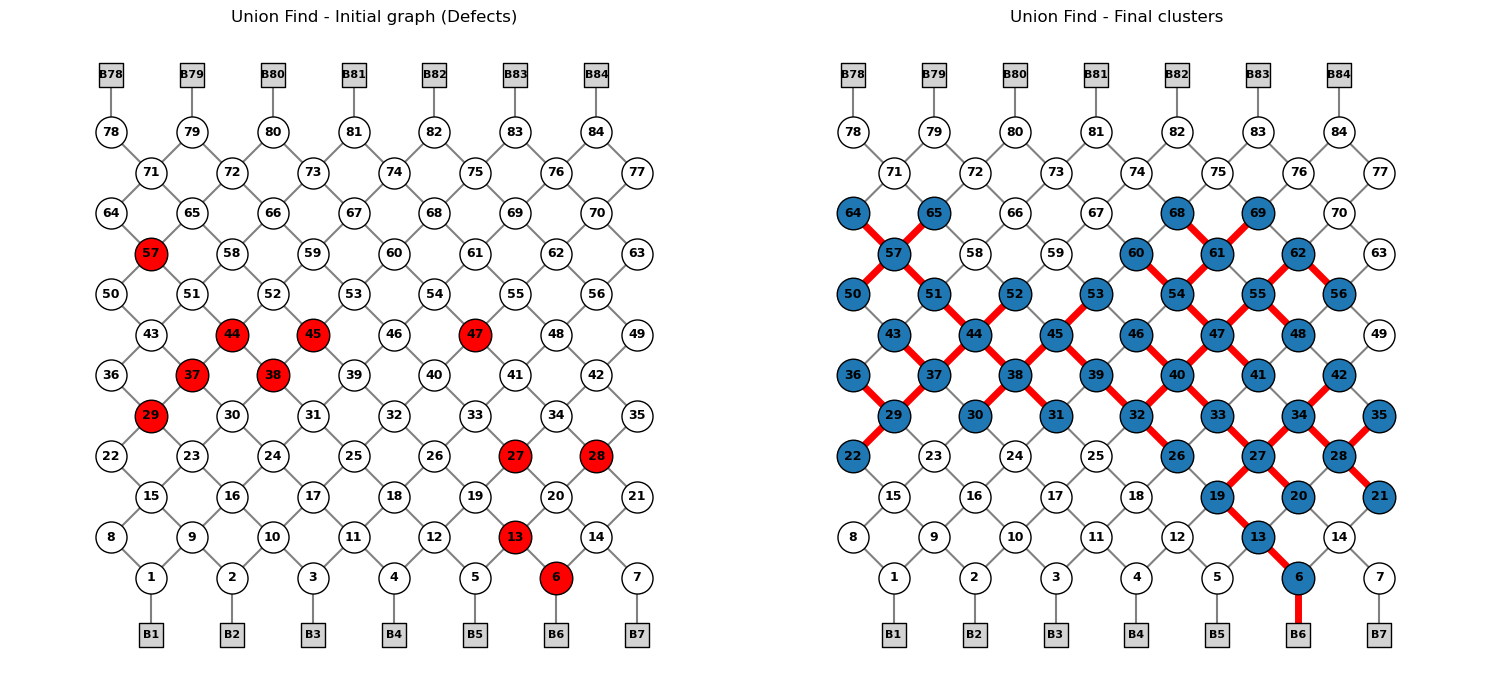

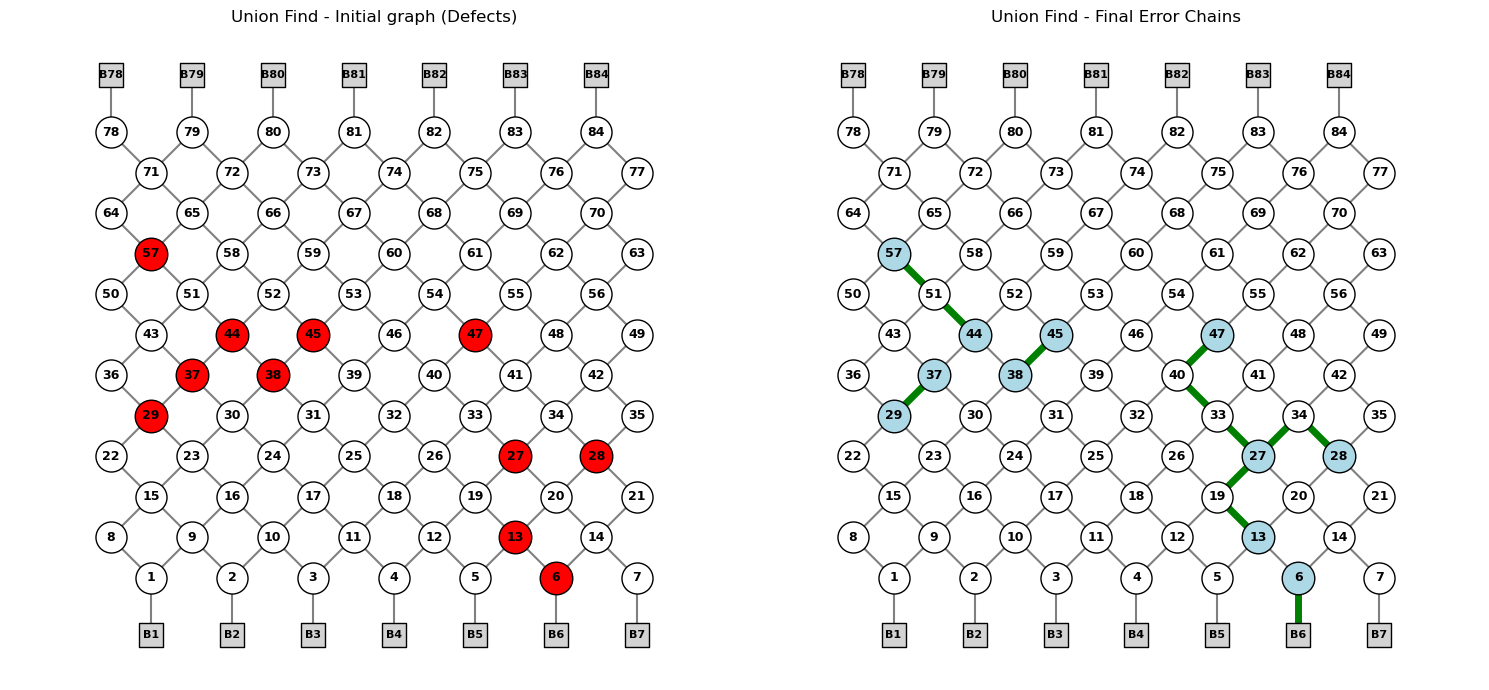

In [5]:
dets = []
boundary_nodes = []
for i in G.nodes:
    if type(i) == int:
        dets.append(i)
    else:
        boundary_nodes.append(i)
Edges = [(u, v) for (u, v) in nx.get_edge_attributes(G, 'weight')]
edges = [(u, v, w) for ((u, v),w) in nx.get_edge_attributes(G, 'weight').items()]

defects = [6,37,38,45,44,57,47, 28,29, 13, 27]

data = {}
data['All_nodes'], data['detector_nodes'], data['edges'], data['boundary_nodes'], data["coord_by_det"] = G.nodes, dets, edges, boundary_nodes, pos
# UF Decoding
clusters, parity, touches_boundary, cluster_edges , cluster_leaf,Node_degree,  highlight_edges, clusters_vs  = uf_cluster_growth(
    dets, edges, defects, boundary_nodes)

# visualize
visualize_uf_run(
    uf_graph=data,
    defects=defects,
    clusters=clusters_vs,
    highlight_edges = highlight_edges
)

Error_chains, Error_visual = find_error_chain(clusters, touches_boundary, cluster_edges , cluster_leaf, Node_degree, defects)

# visualize
final_visualize(
    uf_graph=data,
    defects=defects,
    clusters=clusters_vs,
    highlight_edges = Error_visual
)